# Exploration des données : YouTube Shorts Prediction

Ce notebook permet d'explorer le fichier `raw_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration visuelle des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Chargement des données
On va charger notre jeu de données complet regroupant les vidéos et les informations des chaînes.

In [2]:
file_path = "raw_data.csv"
df = pd.read_csv(file_path)
df.head()

/var/folders/32/gl897mz17tv8kwkkm7t67vc80000gn/T/ipykernel_38615/3738538063.py:2: DtypeWarning: Columns (0: comments) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,id,title,description,publishedAt,duration,channelId,tags,topics,views,likes,...,upload_frequency_days,pct_vertical,pct_has_music,avg_title_length,avg_hook_count,avg_emoji_count,pct_has_hashtag,viral_video_rate,views_per_subscriber,consistency_score
0,4cdJzQWWkE0,"33.87 Seconds! Tru-Dad Solve 🤣 Clock R1,S2 OOC...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-12T06:00:02Z,PT1M4S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],770.0,23.0,...,NaN,0.0,0.0,94.9,0.2333,0.1667,1.0,0.0,0.0,NaN
1,7jdDyK-cbzQ,"3.87 Seconds! 2x2 Finals, S3 OOC '26 #shorts #...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-11T22:00:14Z,PT25S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],5590.0,127.0,...,NaN,0.0,0.0,94.9,0.2333,0.1667,1.0,0.0,0.0,NaN
2,mqOwORyR5uE,"4.18 Seconds! 2x2 Finals, S2 - OOC '26 #youtub...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-11T14:01:11Z,PT29S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],10733.0,231.0,...,NaN,0.0,0.0,94.9,0.2333,0.1667,1.0,0.0,0.0,NaN
3,4CKYtqEzruI,"48.21 Seconds! Tru-Dad Solve 🤣 Clock R1, S1 - ...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-11T06:00:05Z,PT1M17S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],5896.0,189.0,...,NaN,0.0,0.0,94.9,0.2333,0.1667,1.0,0.0,0.0,NaN
4,eUSbUCYMjr0,"5.28 Seconds! 2x2 Finals, S1 - OOC '26 #fyp #f...",Visit @SpeedCubeShopOfficial and use code TRU ...,2026-03-10T06:00:28Z,PT36S,UCVnG-v6mxUHOB0i5cMUKnng,[],[],9959.0,264.0,...,NaN,0.0,0.0,94.9,0.2333,0.1667,1.0,0.0,0.0,NaN


## 2. Informations Générales
Regardons la taille de notre base de données et les types de données qu'elle contient.

In [3]:
print(f"Dimensions du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.\n")
df.info()

Dimensions du dataset : 61648 lignes et 36 colonnes.

<class 'pandas.DataFrame'>
RangeIndex: 61648 entries, 0 to 61647
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     61648 non-null  str    
 1   title                  61643 non-null  str    
 2   description            33345 non-null  str    
 3   publishedAt            61642 non-null  str    
 4   duration               61642 non-null  str    
 5   channelId              61642 non-null  str    
 6   tags                   61642 non-null  str    
 7   topics                 61642 non-null  str    
 8   views                  61642 non-null  float64
 9   likes                  56389 non-null  float64
 10  comments               58432 non-null  object 
 11  thumbnails             61642 non-null  str    
 12  date                   61637 non-null  str    
 13  channel_id             61637 non-null  str    
 14  channel_nam

## 3. Valeurs Manquantes et Doublons
Il est important de nettoyer la donnée avant de l'exploiter.

In [4]:
missing_values = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing_values[missing_values > 0])

print(f"\nNombre de doublons : {df.duplicated().sum()}")

Valeurs manquantes par colonne :
title                        5
description              28303
publishedAt                  6
duration                     6
channelId                    6
tags                         6
topics                       6
views                        6
likes                     5259
comments                  3216
thumbnails                   6
date                        11
channel_id                  11
channel_name                11
subscriber_count            11
creator_tier                11
total_videos                11
channel_age_days         61648
shorts_count_sample         11
avg_views                   11
median_views                11
std_views                   11
max_views                   11
avg_like_rate               11
avg_duration_sec            11
upload_frequency_days    61648
pct_vertical                11
pct_has_music               11
avg_title_length            11
avg_hook_count              11
avg_emoji_count             11
pct_ha

## 4. Statistiques Descriptives
Voici un aperçu des statistiques de base des colonnes au format numérique (moyenne, écart-type, min/max, quartiles).

In [5]:
df.describe()

,views,likes,subscriber_count,total_videos,channel_age_days,shorts_count_sample,avg_views,median_views,std_views,max_views,...,upload_frequency_days,pct_vertical,pct_has_music,avg_title_length,avg_hook_count,avg_emoji_count,pct_has_hashtag,viral_video_rate,views_per_subscriber,consistency_score
count,6.164200e+04,5.638900e+04,61637.0,61637.000000,0.0,61637.000000,61637.0,61637.0,61637.0,61637.0,...,0.0,61637.0,61637.0,61637.000000,61637.000000,61637.000000,61637.000000,61637.0,61637.0,0.0
mean,1.092743e+06,2.777654e+04,0.0,1576.538751,NaN,29.966043,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,64.728665,0.545082,0.667380,0.863267,0.0,0.0,NaN
std,1.387391e+07,2.227079e+05,0.0,1255.753031,NaN,0.778528,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,20.818579,0.737064,0.640805,0.267729,0.0,0.0,NaN
min,0.000000e+00,0.000000e+00,0.0,1.000000,NaN,1.000000,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,14.630000,0.000000,0.000000,0.000000,0.0,0.0,NaN
25%,1.698000e+03,4.100000e+01,0.0,625.000000,NaN,30.000000,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,48.770000,0.100000,0.100000,0.833300,0.0,0.0,NaN
50%,8.165500e+03,2.220000e+02,0.0,1228.000000,NaN,30.000000,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,64.330000,0.200000,0.600000,1.000000,0.0,0.0,NaN
75%,3.728650e+04,1.096000e+03,0.0,2029.000000,NaN,30.000000,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,83.630000,0.500000,1.000000,1.000000,0.0,0.0,NaN
max,2.130498e+09,2.220633e+07,0.0,13896.000000,NaN,30.000000,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,98.770000,3.633300,4.866700,1.000000,0.0,0.0,NaN


## 5. Visualisations
On va tracer quelques graphiques pour mieux comprendre nos données, notamment les corrélations, la distribution des vues, et la relation vues/abonnés.

In [6]:
# Sélectionner quelques colonnes numériques pertinentes qu'on a vraisemblablement dans notre dataset
numerical_cols = [
    'views', 'likes', 'comments', 'duration', 'subscriber_count', 
    'total_videos', 'shorts_count_sample', 'avg_views', 'median_views'
]
available_num_cols = [col for col in numerical_cols if col in df.columns]

if available_num_cols:
    plt.figure(figsize=(10, 8))
    corr_matrix = df[available_num_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Matrice de corrélation des métriques principales')
    plt.show()

ValueError: could not convert string to float: 'https://i.ytimg.com/vi/HXq9U3KpYZs/default.jpg'

<Figure size 1000x800 with 0 Axes>

/Users/antoinebarberin/Desktop/Youtube_shorts prediction/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


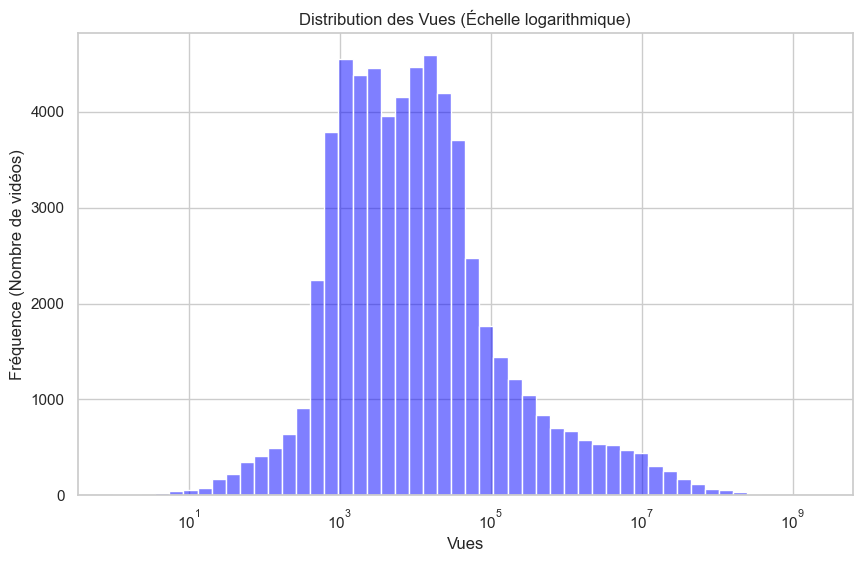

In [7]:
if 'views' in df.columns:
    plt.figure()
    sns.histplot(df['views'], bins=50, kde=True, log_scale=True, color='blue')
    plt.title('Distribution des Vues (Échelle logarithmique)')
    plt.xlabel('Vues')
    plt.ylabel('Fréquence (Nombre de vidéos)')
    plt.show()

/Users/antoinebarberin/Desktop/Youtube_shorts prediction/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


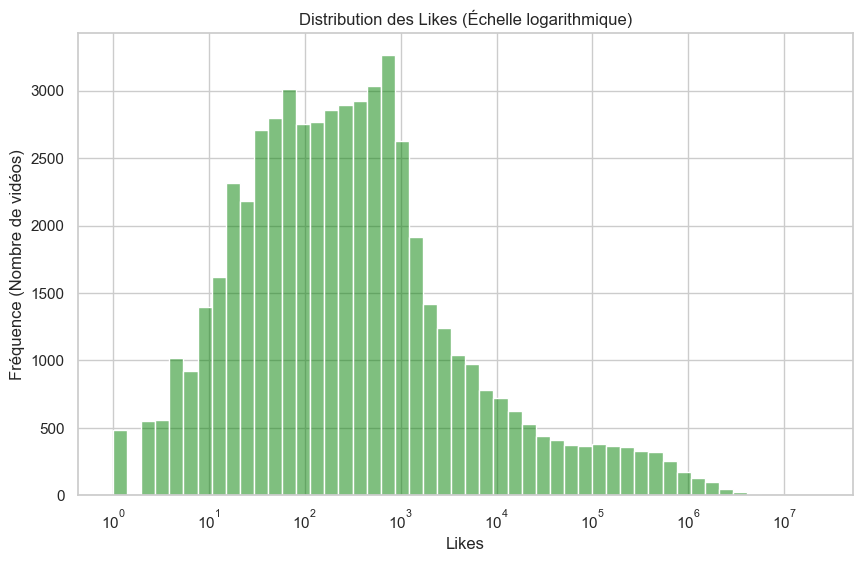

In [8]:
if 'likes' in df.columns:
    plt.figure()
    sns.histplot(df['likes'], bins=50, kde=True, log_scale=True, color='green')
    plt.title('Distribution des Likes (Échelle logarithmique)')
    plt.xlabel('Likes')
    plt.ylabel('Fréquence (Nombre de vidéos)')
    plt.show()

/var/folders/32/gl897mz17tv8kwkkm7t67vc80000gn/T/ipykernel_38615/1841568833.py:4: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xscale('log')


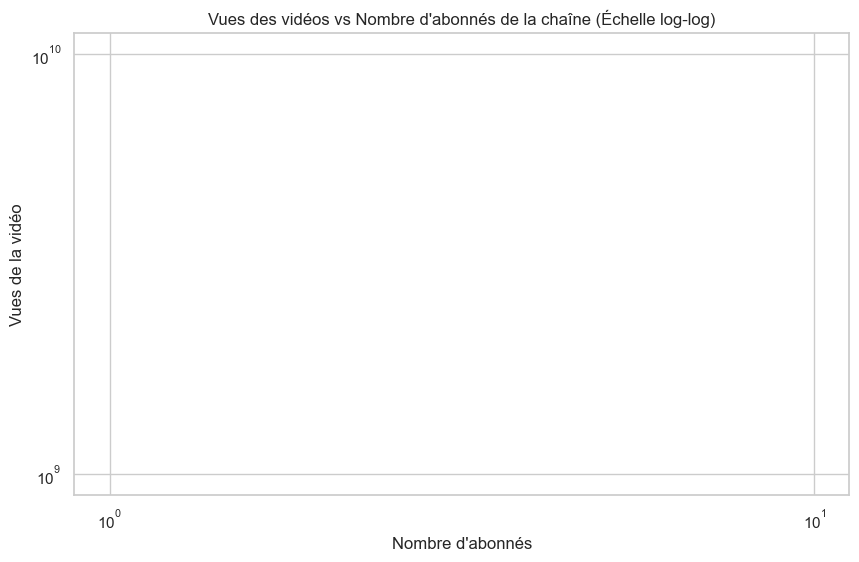

In [9]:
if 'subscriber_count' in df.columns and 'views' in df.columns:
    plt.figure()
    sns.scatterplot(x='subscriber_count', y='views', data=df, alpha=0.3)
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Vues des vidéos vs Nombre d\'abonnés de la chaîne (Échelle log-log)')
    plt.xlabel('Nombre d\'abonnés')
    plt.ylabel('Vues de la vidéo')
    plt.show()

In [ ]:
# Vérification des anomalies d'interactions par rapport aux vues
anomalies = df[ (df['likes'] + df['comments']) > df['views'] ]
nb_anomalies = len(anomalies)

print(f"Vidéos avec plus d'interactions que de vues : {nb_anomalies} sur {len(df)} vidéos.")
if nb_anomalies > 0:
    display(anomalies[['id', 'views', 'likes', 'comments', 'virality_score']].head(10))
